# 🚀 **SLR-33 | Verificação de Pré-decolagem**

***Equipe Tribo Solarian.***

O script de pré-decolagem está separado em partes neste arquivo. Cada parte tem uma célula de apresentação (o que é cada seção  e como funciona) seguida de uma célula de código (implementação, testes e validações com dados reais).

O núcleo determinístico (Partes 0 a 7) implementa os itens 1.1 a 1.4 do projeto. A camada de IA (Partes 8 a 12) implementa o item 1.5. A análise assistida por IA opera com dois modelos simples que rodam em paralelo, um para comparar e validar a classificação, outro para analisar causas e consequências.

###### **Repositório do projeto:**
<https://github.com/claudioreissilveira/Tribo-Solarian>

## ***Integrantes:***
- **Cláudio Roberto Grillo Reis Silveira | RM575353**
- **Vitor Lima Montiel | RM575458**
- **Wallace Gabriel Américo Albuquerque | RM575435**
- **Victor Augusto dos Santos Souza | RM576021**
- **Thales Martins Olveira Barros | RM574664**

## Sumário

- Parte 0, bibliotecas
- Parte 1, limiares e constantes (item 1.1 + 1.2)
- Parte 2, estrutura da leitura de telemetria
- Parte 3, entrada de dados manual (input)
- Parte 4, classificação por variável
- Parte 5, eficiência energética (item 1.4)
- Parte 6, regra de decisão determinística (decisão oficial, item 1.2)
- Parte 7, teste manual do núcleo determinístico
- Parte 8, conjunto de dados sintético para treino
- Parte 9, separação treino e teste
- Parte 10, Modelo 1, classificador de status (item 1.5)
- Parte 11, Modelo 2, classificador de causa provável (item 1.5)
- Parte 12, execução integrada (regras + Modelo 1 + Modelo 2)
- Parte 13, testes finais e casos de validação
- Parte 14, conclusão

## **Parte 0, Bibliotecas**

Bibliotecas padrão do Python usadas em todo o script, `enum`, `dataclasses`, `random`, `json`.

Bibliotecas visuais, `colorama` (cores no terminal) e `tabulate` (tabelas no terminal).

Bibliotecas de dados e IA, já integradas ao Colab, `pandas`, `numpy`, e do `scikit-learn`, `train_test_split`, `DecisionTreeClassifier`, `accuracy_score`.

In [1]:
# Bibliotecas usadas no script
!pip install colorama tabulate

from dataclasses import dataclass
import random

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from colorama import Fore, Style
from tabulate import tabulate


## **Parte 1, Limiares e constantes (item 1.1 + 1.2)**

Tabela de limiares, com valores inspirados em referências reais de engenharia aeroespacial.

| Variável | Unidade | Verde | Amarelo | Vermelho |
|---|---|---|---|---|
| Temperatura interna | °C | 21 a 25 | 18 a 21 ou 25 a 27 | abaixo de 18 ou acima de 27 |
| Temperatura externa | °C | 5 a 35 | -5 a 5 ou 35 a 45 | abaixo de -5 ou acima de 45 |
| Energia (carga da bateria) | % | 85 a 100 | 60 a 85 | abaixo de 60 |
| Pressão tanque hélio | psi | 5500 a 6500 | 4500 a 5500 ou 6500 a 7000 | abaixo de 4500 ou acima de 7000 |
| Pressão tanque propelente | psi | 240 a 260 | 220 a 240 ou 260 a 280 | abaixo de 220 ou acima de 280 |

Integridade estrutural, binária, `1` para íntegra e `0` para comprometida, sem faixa intermediária.

Módulos críticos, categórica, com três estados possíveis, `"OK"`, `"ALERTA"` e `"FALHA"`, um valor para cada um destes cinco módulos, `propulsao`, `suporte_vida`, `avionica`, `comunicacao` e `energia_eletrica`.

In [2]:
""" Cada faixa "amarelo" abaixo já inclui a faixa "verde" por dentro. Por isso a
   classificação (Parte 4) só precisa checar verde e depois amarelo, nessa ordem. """

# Temperatura interna (°C)
TEMP_INT_VERDE = (21, 25)
TEMP_INT_AMARELO = (18, 27)

# Temperatura externa (°C)
TEMP_EXT_VERDE = (5, 35)
TEMP_EXT_AMARELO = (-5, 45)

# Energia, carga da bateria (%)
ENERGIA_VERDE_MIN = 85
ENERGIA_AMARELO_MIN = 60

# Pressão do tanque de hélio (psi)
PRESSAO_HELIO_VERDE = (5500, 6500)
PRESSAO_HELIO_AMARELO = (4500, 7000)

# Pressão do tanque de propelente (psi)
PRESSAO_PROP_VERDE = (240, 260)
PRESSAO_PROP_AMARELO = (220, 280)

# Módulos críticos
NOMES_MODULOS = ["propulsao", "suporte_vida", "avionica", "comunicacao", "energia_eletrica"]
ESTADOS_MODULO = ["OK", "ALERTA", "FALHA"]

# Teste com dado real, verificando limiares antes de seguir
print("Faixa verde da temperatura interna:", TEMP_INT_VERDE)
print("Faixa amarela da temperatura interna:", TEMP_INT_AMARELO)
print("Faixa verde da pressão do hélio:", PRESSAO_HELIO_VERDE)


Faixa verde da temperatura interna: (21, 25)
Faixa amarela da temperatura interna: (18, 27)
Faixa verde da pressão do hélio: (5500, 6500)


## **Parte 2, Estrutura da leitura de telemetria**

Cada leitura da nave é representada por uma `dataclass` chamada `LeituraTelemetria`, com sete campos.

| Campo | Tipo | Unidade / valores |
|---|---|---|
| `temperatura_interna` | `float` | °C |
| `temperatura_externa` | `float` | °C |
| `integridade_estrutural` | `int` | 0 ou 1 |
| `energia` | `float` | %, carga da bateria |
| `pressao_tanque_helio` | `float` | psi |
| `pressao_tanque_propelente` | `float` | psi |
| `modulos` | `dict` | 5 chaves da Parte 1, cada uma `"OK"` / `"ALERTA"` / `"FALHA"` |

In [3]:
# Estrutura de uma leitura completa de telemetria (item 1.1)
@dataclass
class LeituraTelemetria:
    temperatura_interna: float
    temperatura_externa: float
    integridade_estrutural: int
    energia: float
    pressao_tanque_helio: float
    pressao_tanque_propelente: float
    modulos: dict


# Leitura de exemplo com valores nominais
leitura_exemplo = LeituraTelemetria(
    temperatura_interna=23.0,
    temperatura_externa=20.0,
    integridade_estrutural=1,
    energia=95.0,
    pressao_tanque_helio=6000.0,
    pressao_tanque_propelente=250.0,
    modulos={
        "propulsao": "OK",
        "suporte_vida": "OK",
        "avionica": "OK",
        "comunicacao": "OK",
        "energia_eletrica": "OK",
    },
)
print(leitura_exemplo)


LeituraTelemetria(temperatura_interna=23.0, temperatura_externa=20.0, integridade_estrutural=1, energia=95.0, pressao_tanque_helio=6000.0, pressao_tanque_propelente=250.0, modulos={'propulsao': 'OK', 'suporte_vida': 'OK', 'avionica': 'OK', 'comunicacao': 'OK', 'energia_eletrica': 'OK'})


## **Parte 3, Entrada de dados manual (input)**

Esta parte é responsável pela captura manual de uma leitura completa, digitada pelo usuário, nesta ordem.

1. Temperatura interna (°C)
2. Temperatura externa (°C)
3. Integridade estrutural (0 ou 1)
4. Energia, carga da bateria (%)
5. Pressão do tanque de hélio (psi)
6. Pressão do tanque de propelente (psi)
7. Status do módulo `propulsao`
8. Status do módulo `suporte_vida`
9. Status do módulo `avionica`
10. Status do módulo `comunicacao`
11. Status do módulo `energia_eletrica`

A captura segue estas regras de validação.

- O campo `integridade_estrutural` aceita somente `0` ou `1`.
- Cada um dos 5 módulos aceita somente `"OK"`, `"ALERTA"` ou `"FALHA"` (maiúsculas).
- Cada input é protegido por um laço de repetição com tratamento de erro, pedindo o valor de novo em caso de falha na conversão, ao invés de interromper a execução.
- A unidade correspondente aparece no próprio texto do input, ex. `"Temperatura interna (°C): "`.

In [4]:
# Pede um número para o usuário, trocando a vírgula pelo ponto e pedindo de novo em caso de erro
def pedir_numero(mensagem):
    while True:
        texto = input(mensagem).strip().replace(",", ".")
        try:
            return float(texto)
        except ValueError:
            print("Valor inválido, digite um número (ex. 23.5).")


# Pede a integridade estrutural, 0 ou 1
def pedir_integridade():
    while True:
        texto = input("Integridade estrutural (0 ou 1): ").strip()
        if texto in ("0", "1"):
            return int(texto)
        print("Valor inválido, digite 0 ou 1.")


# Pede o status de um módulo, aceita OK, ALERTA ou FALHA
def pedir_status_modulo(nome_modulo):
    while True:
        texto = input(f"Status do módulo {nome_modulo} (OK, ALERTA ou FALHA): ").strip().upper()
        if texto in ESTADOS_MODULO:
            return texto
        print("Valor inválido, digite OK, ALERTA ou FALHA.")


# Junta os pedidos acima, na ordem do item 1.1, e monta a LeituraTelemetria
def ler_telemetria_manual():
    temperatura_interna = pedir_numero("Temperatura interna (°C): ")
    temperatura_externa = pedir_numero("Temperatura externa (°C): ")
    integridade_estrutural = pedir_integridade()
    energia = pedir_numero("Energia, carga da bateria (%): ")
    pressao_tanque_helio = pedir_numero("Pressão do tanque de hélio (psi): ")
    pressao_tanque_propelente = pedir_numero("Pressão do tanque de propelente (psi): ")

    modulos = {}
    for nome_modulo in NOMES_MODULOS:
        modulos[nome_modulo] = pedir_status_modulo(nome_modulo)

    return LeituraTelemetria(
        temperatura_interna,
        temperatura_externa,
        integridade_estrutural,
        energia,
        pressao_tanque_helio,
        pressao_tanque_propelente,
        modulos,
    )


# Digitar valores nominais quando a célula pedir
# (ex. 23 / 20 / 1 / 95 / 6000 / 250 / OK / OK / OK / OK / OK)
leitura_manual = ler_telemetria_manual()
print(leitura_manual)


Temperatura interna (°C): 24
Temperatura externa (°C): 34
Integridade estrutural (0 ou 1): 1
Energia, carga da bateria (%): 87
Pressão do tanque de hélio (psi): 6000
Pressão do tanque de propelente (psi): 5500
Status do módulo propulsao (OK, ALERTA ou FALHA): OK
Status do módulo suporte_vida (OK, ALERTA ou FALHA): ALERTA
Status do módulo avionica (OK, ALERTA ou FALHA): OK
Status do módulo comunicacao (OK, ALERTA ou FALHA): OK
Status do módulo energia_eletrica (OK, ALERTA ou FALHA): ALERTA
LeituraTelemetria(temperatura_interna=24.0, temperatura_externa=34.0, integridade_estrutural=1, energia=87.0, pressao_tanque_helio=6000.0, pressao_tanque_propelente=5500.0, modulos={'propulsao': 'OK', 'suporte_vida': 'ALERTA', 'avionica': 'OK', 'comunicacao': 'OK', 'energia_eletrica': 'ALERTA'})


## **Parte 4, Classificação por variável (item 1.1 + 1.2)**

Cinco funções, uma por variável contínua, cada uma recebendo o valor lido e devolvendo a classificação correspondente, `"verde"`, `"amarelo"` ou `"vermelho"`, de acordo com os limiares da Parte 1.

- `classificar_temperatura_interna(valor)`
- `classificar_temperatura_externa(valor)`
- `classificar_energia(valor)`
- `classificar_pressao_helio(valor)`
- `classificar_pressao_propelente(valor)`

Integridade estrutural e módulos críticos não passam por esta classificação, chegam prontos (`0`/`1` e `"OK"`/`"ALERTA"`/`"FALHA"`).

In [5]:
# Uma função contínua, classifica em verde, amarelo ou vermelho
def classificar_temperatura_interna(valor):
    if TEMP_INT_VERDE[0] <= valor <= TEMP_INT_VERDE[1]:
        return "verde"
    elif TEMP_INT_AMARELO[0] <= valor <= TEMP_INT_AMARELO[1]:
        return "amarelo"
    else:
        return "vermelho"


def classificar_temperatura_externa(valor):
    if TEMP_EXT_VERDE[0] <= valor <= TEMP_EXT_VERDE[1]:
        return "verde"
    elif TEMP_EXT_AMARELO[0] <= valor <= TEMP_EXT_AMARELO[1]:
        return "amarelo"
    else:
        return "vermelho"


def classificar_energia(valor):
    if valor >= ENERGIA_VERDE_MIN:
        return "verde"
    elif valor >= ENERGIA_AMARELO_MIN:
        return "amarelo"
    else:
        return "vermelho"


def classificar_pressao_helio(valor):
    if PRESSAO_HELIO_VERDE[0] <= valor <= PRESSAO_HELIO_VERDE[1]:
        return "verde"
    elif PRESSAO_HELIO_AMARELO[0] <= valor <= PRESSAO_HELIO_AMARELO[1]:
        return "amarelo"
    else:
        return "vermelho"


def classificar_pressao_propelente(valor):
    if PRESSAO_PROP_VERDE[0] <= valor <= PRESSAO_PROP_VERDE[1]:
        return "verde"
    elif PRESSAO_PROP_AMARELO[0] <= valor <= PRESSAO_PROP_AMARELO[1]:
        return "amarelo"
    else:
        return "vermelho"


# Testes sintéticos para verificação
print(classificar_temperatura_interna(23))
print(classificar_temperatura_interna(19))
print(classificar_pressao_helio(4000))


verde
amarelo
vermelho


## **Parte 5, Autonomia energética (item 1.4)**

Valores de referência da SLR-33, adotados como padrão para o cálculo.

| Grandeza | Valor de referência |
|---|---|
| Capacidade total | 25 kWh |
| Carga atual | 96% |
| Potência média de decolagem | 6,5 kW |
| Perdas energéticas | 6% da energia disponível |
| Duração estimada da decolagem | 12 minutos (0,2 h) |

O cálculo segue esta sequência.

1. `energia_disponivel = capacidade_total * carga_atual`
2. `energia_liquida = energia_disponivel - perdas_energeticas`
3. `consumo_estimado = potencia_media * duracao`
4. `autonomia_restante = energia_liquida - consumo_estimado`

Uma `autonomia_restante` negativa caracteriza energia insuficiente, condição que aciona a Regra 1 da Parte 6.

In [6]:
CAPACIDADE_TOTAL_KWH = 25
CARGA_ATUAL = 0.96
POTENCIA_MEDIA_KW = 6.5
PERDAS_PERCENTUAL = 0.06
DURACAO_HORAS = 0.2


# Aplica as fórmulas da autonomia energética, na ordem
def calcular_autonomia(capacidade_total, carga_atual, potencia_media, perdas, duracao):
    energia_disponivel = capacidade_total * carga_atual
    perdas_energeticas = energia_disponivel * perdas
    energia_liquida = energia_disponivel - perdas_energeticas
    consumo_estimado = potencia_media * duracao
    autonomia_restante = energia_liquida - consumo_estimado
    return autonomia_restante


# Testes com os valores de referência da SLR-33
autonomia_referencia = calcular_autonomia(
    CAPACIDADE_TOTAL_KWH, CARGA_ATUAL, POTENCIA_MEDIA_KW, PERDAS_PERCENTUAL, DURACAO_HORAS
)
print("Autonomia restante (kWh):", round(autonomia_referencia, 2))


Autonomia restante (kWh): 21.26


## **Parte 6, Regra de decisão determinística (decisão oficial, item 1.2)**

A decisão final é sempre uma destas três classificações, aplicadas nesta ordem de prioridade.

- `"ABORTADA"`, quando qualquer variável está `"vermelho"`, ou `integridade_estrutural` é `0`, ou qualquer módulo está em `"FALHA"`, ou a autonomia restante é negativa.
- `"ALERTA"`, quando nenhuma condição crítica ocorre, mas existe alguma variável em `"amarelo"` ou algum módulo em `"ALERTA"`.
- `"PRONTO"`, quando todas as variáveis estão `"verde"`, a integridade é `1`, todos os módulos estão `"OK"`, e a autonomia é positiva.

In [7]:
# Aplica as regras de decisão, por ordem de prioridade
def decidir_decolagem(leitura, autonomia_restante):
    classificacoes = {
        "temperatura interna": classificar_temperatura_interna(leitura.temperatura_interna),
        "temperatura externa": classificar_temperatura_externa(leitura.temperatura_externa),
        "energia": classificar_energia(leitura.energia),
        "pressão tanque hélio": classificar_pressao_helio(leitura.pressao_tanque_helio),
        "pressão tanque propelente": classificar_pressao_propelente(leitura.pressao_tanque_propelente),
    }

    # Regra 1, crítica
    motivos_criticos = []
    if autonomia_restante < 0:
        motivos_criticos.append("autonomia energética insuficiente")
    if leitura.integridade_estrutural == 0:
        motivos_criticos.append("integridade estrutural comprometida")
    for nome, cor in classificacoes.items():
        if cor == "vermelho":
            motivos_criticos.append(f"{nome} em vermelho")
    for nome_modulo, status in leitura.modulos.items():
        if status == "FALHA":
            motivos_criticos.append(f"módulo {nome_modulo} em falha")

    if motivos_criticos:
        return "ABORTADA", motivos_criticos

    # Regra 2, atenção
    motivos_atencao = []
    for nome, cor in classificacoes.items():
        if cor == "amarelo":
            motivos_atencao.append(f"{nome} em amarelo")
    for nome_modulo, status in leitura.modulos.items():
        if status == "ALERTA":
            motivos_atencao.append(f"módulo {nome_modulo} em alerta")

    if motivos_atencao:
        return "ALERTA", motivos_atencao

    # Regra 3, nominal
    return "PRONTO", []


# Duas leituras conhecidas
motivos_ok = {"propulsao": "OK", "suporte_vida": "OK", "avionica": "OK", "comunicacao": "OK", "energia_eletrica": "OK"}

leitura_nominal_teste = LeituraTelemetria(23, 20, 1, 95, 6000, 250, motivos_ok)
print(decidir_decolagem(leitura_nominal_teste, autonomia_referencia))  # ("PRONTO", [])

leitura_critica_teste = LeituraTelemetria(23, 20, 0, 95, 6000, 250, motivos_ok)
print(decidir_decolagem(leitura_critica_teste, autonomia_referencia))  # ("ABORTADA", [...])


('PRONTO', [])
('ABORTADA', ['integridade estrutural comprometida'])


## **Parte 7, Teste manual do núcleo determinístico**

Esta parte integra as Partes 3 a 6, na seguinte sequência.

1. Leitura manual (Parte 3).
2. Classificação das 5 variáveis contínuas (Parte 4).
3. Cálculo da autonomia (Parte 5).
4. Decisão (Parte 6).
5. Apresentação do resultado, uma tabela `tabulate` com uma linha por variável (nome, valor, classificação), seguida da decisão final colorida com `colorama`, verde para `"PRONTO"`, amarelo para `"ALERTA"`, vermelho para `"ABORTADA"`.

Ponto de validação dos itens 1.1 a 1.4 do enunciado, antes da camada com IA assistida.

In [8]:
# Monta a tabela com cada variável e imprime o resultado final colorido
def mostrar_resultado(leitura, autonomia_restante, decisao, motivos):
    linhas = [
        ["Temperatura interna", f"{leitura.temperatura_interna} °C", classificar_temperatura_interna(leitura.temperatura_interna)],
        ["Temperatura externa", f"{leitura.temperatura_externa} °C", classificar_temperatura_externa(leitura.temperatura_externa)],
        ["Integridade estrutural", leitura.integridade_estrutural, "íntegra" if leitura.integridade_estrutural == 1 else "comprometida"],
        ["Energia", f"{leitura.energia} %", classificar_energia(leitura.energia)],
        ["Pressão tanque hélio", f"{leitura.pressao_tanque_helio} psi", classificar_pressao_helio(leitura.pressao_tanque_helio)],
        ["Pressão tanque propelente", f"{leitura.pressao_tanque_propelente} psi", classificar_pressao_propelente(leitura.pressao_tanque_propelente)],
    ]
    for nome_modulo, status in leitura.modulos.items():
        linhas.append([f"Módulo {nome_modulo}", "-", status])

    print(tabulate(linhas, headers=["Variável", "Valor", "Classificação"]))
    print(f"Autonomia restante, {round(autonomia_restante, 2)} kWh")

    cor_por_decisao = {"PRONTO": Fore.GREEN, "ALERTA": Fore.YELLOW, "ABORTADA": Fore.RED}
    cor = cor_por_decisao[decisao]
    print(cor + f"Decisão final, {decisao}" + Style.RESET_ALL)
    if motivos:
        print("Motivos:", ", ".join(motivos))


# Leitura real
decisao_manual, motivos_manual = decidir_decolagem(leitura_manual, autonomia_referencia)
mostrar_resultado(leitura_manual, autonomia_referencia, decisao_manual, motivos_manual)


Variável                   Valor       Classificação
-------------------------  ----------  ---------------
Temperatura interna        24.0 °C     verde
Temperatura externa        34.0 °C     verde
Integridade estrutural     1           íntegra
Energia                    87.0 %      verde
Pressão tanque hélio       6000.0 psi  verde
Pressão tanque propelente  5500.0 psi  vermelho
Módulo propulsao           -           OK
Módulo suporte_vida        -           ALERTA
Módulo avionica            -           OK
Módulo comunicacao         -           OK
Módulo energia_eletrica    -           ALERTA
Autonomia restante, 21.26 kWh
Decisão final, ABORTADA
Motivos: pressão tanque propelente em vermelho


## **Parte 8, Conjunto de dados sintético para treino**

Esta parte gera leituras sintéticas para treinar os dois modelos, construídas em três grupos de tamanho aproximadamente igual, para manter as três classes finais equilibradas (sorteio independente e amplo em cada variável, testado à parte, concentrava mais de 90% das leituras em ABORTADA e não servia para treino).

- Nominal, todas as variáveis dentro da própria faixa verde e todos os módulos `"OK"`.
- Com alerta, uma ou duas variáveis escolhidas ao acaso (a segunda em 25% dos casos) são deslocadas para a própria faixa amarela, o resto permanece nominal.
- Com problema crítico, uma ou duas variáveis escolhidas ao acaso (incluindo a integridade estrutural, a segunda em 25% dos casos) são deslocadas para a própria faixa vermelha, ou um módulo é definido como `"FALHA"`, o resto permanece nominal. Ajuste feito para o Modelo 2 aprender a apontar a causa também quando mais de uma variável está fora da faixa.

- `rotulo_status`, a saída de `decidir_decolagem` (Parte 6), `"PRONTO"` / `"ALERTA"` / `"ABORTADA"`.
- `rotulo_causa`, a variável com maior desvio percentual em relação ao limite que ultrapassou, `desvio = abs(limite - valor) / limite * 100`. Para integridade estrutural igual a `0`, o desvio é 100. Para os módulos, `"OK"` vale 0, `"ALERTA"` vale 50 e `"FALHA"` vale 100. Quando todos os desvios são 0, a causa é `"nenhuma"`.

Para que os módulos entrem no dataset em formato numérico, cada um dos 5 é representado em uma coluna própria, `"OK"` = 0, `"ALERTA"` = 1, `"FALHA"` = 2.

O conjunto final é um `pandas.DataFrame`, uma linha por leitura, com as 13 colunas, `temperatura_interna`, `temperatura_externa`, `integridade_estrutural`, `energia`, `pressao_tanque_helio`, `pressao_tanque_propelente`, `modulo_propulsao`, `modulo_suporte_vida`, `modulo_avionica`, `modulo_comunicacao`, `modulo_energia_eletrica`, `rotulo_status`, `rotulo_causa`.

In [9]:
N_AMOSTRAS = 4000

MAPA_STATUS_MODULO = {"OK": 0, "ALERTA": 1, "FALHA": 2}
VALOR_DESVIO_MODULO = {"OK": 0, "ALERTA": 50, "FALHA": 100}

# Variáveis contínuas de dois lados, (faixa verde, faixa amarela) de cada uma
VARIAVEIS_2LADOS = {
    "temperatura_interna": (TEMP_INT_VERDE, TEMP_INT_AMARELO),
    "temperatura_externa": (TEMP_EXT_VERDE, TEMP_EXT_AMARELO),
    "pressao_tanque_helio": (PRESSAO_HELIO_VERDE, PRESSAO_HELIO_AMARELO),
    "pressao_tanque_propelente": (PRESSAO_PROP_VERDE, PRESSAO_PROP_AMARELO),
}

# Variáveis que podem ficar "amarelo", e as que podem ficar "vermelho"
VARIAVEIS_COM_AMARELO = list(VARIAVEIS_2LADOS.keys()) + ["energia"] + NOMES_MODULOS
VARIAVEIS_COM_VERMELHO = VARIAVEIS_COM_AMARELO + ["integridade_estrutural"]


# Gera uma leitura, tudo verde/OK
def gerar_leitura_nominal():
    modulos = {nome: "OK" for nome in NOMES_MODULOS}
    return LeituraTelemetria(
        random.uniform(TEMP_INT_VERDE[0], TEMP_INT_VERDE[1]),
        random.uniform(TEMP_EXT_VERDE[0], TEMP_EXT_VERDE[1]),
        1,
        random.uniform(ENERGIA_VERDE_MIN, 100),
        random.uniform(PRESSAO_HELIO_VERDE[0], PRESSAO_HELIO_VERDE[1]),
        random.uniform(PRESSAO_PROP_VERDE[0], PRESSAO_PROP_VERDE[1]),
        modulos,
    )


def valor_amarelo(faixa_verde, faixa_amarela):
    """Sorteia um valor dentro da faixa amarela, mas fora da faixa verde."""
    if random.random() < 0.5:
        return random.uniform(faixa_amarela[0], faixa_verde[0])
    return random.uniform(faixa_verde[1], faixa_amarela[1])


def valor_vermelho(faixa_amarela):
    """Sorteia um valor fora da faixa amarela inteira."""
    margem = (faixa_amarela[1] - faixa_amarela[0]) * 0.3
    if random.random() < 0.5:
        return random.uniform(faixa_amarela[0] - margem, faixa_amarela[0])
    return random.uniform(faixa_amarela[1], faixa_amarela[1] + margem)


def gerar_leitura_com_problema(nivel):
    """nivel é "amarelo" ou "vermelho". Parte de uma leitura nominal e desloca uma
    variável, escolhida ao acaso, para aquele local."""
    leitura = gerar_leitura_nominal()
    pool = VARIAVEIS_COM_AMARELO if nivel == "amarelo" else VARIAVEIS_COM_VERMELHO
    quantidade = 2 if random.random() < 0.25 else 1
    variaveis_escolhidas = random.sample(pool, k=quantidade)

    for variavel in variaveis_escolhidas:
        if variavel in VARIAVEIS_2LADOS:
            faixa_verde, faixa_amarela = VARIAVEIS_2LADOS[variavel]
            novo_valor = valor_amarelo(faixa_verde, faixa_amarela) if nivel == "amarelo" else valor_vermelho(faixa_amarela)
            setattr(leitura, variavel, novo_valor)
        elif variavel == "energia":
            leitura.energia = random.uniform(ENERGIA_AMARELO_MIN, ENERGIA_VERDE_MIN) if nivel == "amarelo" else random.uniform(10, ENERGIA_AMARELO_MIN)
        elif variavel == "integridade_estrutural":
            leitura.integridade_estrutural = 0
        else:
            leitura.modulos[variavel] = "ALERTA" if nivel == "amarelo" else "FALHA"

    return leitura


# Sorteia entre leitura nominal, com alerta ou com problema crítico
def gerar_leitura_sintetica():
    sorteio = random.random()
    if sorteio < 1 / 3:
        return gerar_leitura_nominal()
    elif sorteio < 2 / 3:
        return gerar_leitura_com_problema("amarelo")
    else:
        return gerar_leitura_com_problema("vermelho")


# Desvio percentual de um valor em relação ao limite que ele ultrapassou
def calcular_desvio(valor, limite):
    return abs(limite - valor) / limite * 100


# Aponta a variável com maior desvio, a causa provável do resultado
def causa_provavel(leitura):
    variaveis_continuas = [
        ("temperatura_interna", leitura.temperatura_interna, TEMP_INT_VERDE),
        ("temperatura_externa", leitura.temperatura_externa, TEMP_EXT_VERDE),
        ("pressao_tanque_helio", leitura.pressao_tanque_helio, PRESSAO_HELIO_VERDE),
        ("pressao_tanque_propelente", leitura.pressao_tanque_propelente, PRESSAO_PROP_VERDE),
    ]

    desvios = {}
    for nome, valor, faixa_verde in variaveis_continuas:
        if valor < faixa_verde[0]:
            desvios[nome] = calcular_desvio(valor, faixa_verde[0])
        elif valor > faixa_verde[1]:
            desvios[nome] = calcular_desvio(valor, faixa_verde[1])
        else:
            desvios[nome] = 0

    # Se energia tem limite inferior
    if leitura.energia < ENERGIA_VERDE_MIN:
        desvios["energia"] = calcular_desvio(leitura.energia, ENERGIA_VERDE_MIN)
    else:
        desvios["energia"] = 0

    # Integridade estrutural
    desvios["integridade_estrutural"] = 100 if leitura.integridade_estrutural == 0 else 0

    # Módulos críticos
    for nome_modulo, status in leitura.modulos.items():
        desvios[nome_modulo] = VALOR_DESVIO_MODULO[status]

    variavel_mais_desviada = max(desvios, key=desvios.get)
    if desvios[variavel_mais_desviada] == 0:
        return "nenhuma"
    return variavel_mais_desviada


linhas_dataset = []
for _ in range(N_AMOSTRAS):
    leitura_sintetica = gerar_leitura_sintetica()
    rotulo_status, _ = decidir_decolagem(leitura_sintetica, autonomia_referencia)
    rotulo_causa = causa_provavel(leitura_sintetica)

    linha = {
        "temperatura_interna": leitura_sintetica.temperatura_interna,
        "temperatura_externa": leitura_sintetica.temperatura_externa,
        "integridade_estrutural": leitura_sintetica.integridade_estrutural,
        "energia": leitura_sintetica.energia,
        "pressao_tanque_helio": leitura_sintetica.pressao_tanque_helio,
        "pressao_tanque_propelente": leitura_sintetica.pressao_tanque_propelente,
        "modulo_propulsao": MAPA_STATUS_MODULO[leitura_sintetica.modulos["propulsao"]],
        "modulo_suporte_vida": MAPA_STATUS_MODULO[leitura_sintetica.modulos["suporte_vida"]],
        "modulo_avionica": MAPA_STATUS_MODULO[leitura_sintetica.modulos["avionica"]],
        "modulo_comunicacao": MAPA_STATUS_MODULO[leitura_sintetica.modulos["comunicacao"]],
        "modulo_energia_eletrica": MAPA_STATUS_MODULO[leitura_sintetica.modulos["energia_eletrica"]],
        "rotulo_status": rotulo_status,
        "rotulo_causa": rotulo_causa,
    }
    linhas_dataset.append(linha)

dataset = pd.DataFrame(linhas_dataset)

# Ver os status presentes no dataset e checar se não há valores nulos
print(dataset["rotulo_status"].value_counts())
print("Linhas com valor nulo:", dataset.isnull().sum().sum())


rotulo_status
ABORTADA    1353
PRONTO      1352
ALERTA      1295
Name: count, dtype: int64
Linhas com valor nulo: 0


## **Parte 9, Separação treino e teste**

O `DataFrame` da Parte 8 é dividido em `X` (as 11 colunas de variáveis) e dois alvos, `y_status` (coluna `rotulo_status`, para o Modelo 1) e `y_causa` (coluna `rotulo_causa`, para o Modelo 2).

In [10]:
COLUNAS_VARIAVEIS = [
    "temperatura_interna", "temperatura_externa", "integridade_estrutural", "energia",
    "pressao_tanque_helio", "pressao_tanque_propelente",
    "modulo_propulsao", "modulo_suporte_vida", "modulo_avionica",
    "modulo_comunicacao", "modulo_energia_eletrica",
]


# Converte LeituraTelemetria no mesmo formato de linha usado no dataset
def leitura_para_linha(leitura):
    return {
        "temperatura_interna": leitura.temperatura_interna,
        "temperatura_externa": leitura.temperatura_externa,
        "integridade_estrutural": leitura.integridade_estrutural,
        "energia": leitura.energia,
        "pressao_tanque_helio": leitura.pressao_tanque_helio,
        "pressao_tanque_propelente": leitura.pressao_tanque_propelente,
        "modulo_propulsao": MAPA_STATUS_MODULO[leitura.modulos["propulsao"]],
        "modulo_suporte_vida": MAPA_STATUS_MODULO[leitura.modulos["suporte_vida"]],
        "modulo_avionica": MAPA_STATUS_MODULO[leitura.modulos["avionica"]],
        "modulo_comunicacao": MAPA_STATUS_MODULO[leitura.modulos["comunicacao"]],
        "modulo_energia_eletrica": MAPA_STATUS_MODULO[leitura.modulos["energia_eletrica"]],
    }


X = dataset[COLUNAS_VARIAVEIS]
y_status = dataset["rotulo_status"]
y_causa = dataset["rotulo_causa"]

X_treino, X_teste, y_status_treino, y_status_teste = train_test_split(
    X, y_status, test_size=0.2, random_state=42
)
# Mesmo X e mesmo random_state, garante a mesma divisão de linhas para o segundo alvo
_, _, y_causa_treino, y_causa_teste = train_test_split(
    X, y_causa, test_size=0.2, random_state=42
)

# Conferir o tamanho de cada divisão
print("Linhas de treino:", len(X_treino))
print("Linhas de teste:", len(X_teste))


Linhas de treino: 3200
Linhas de teste: 800


## **Parte 10, Modelo 1, classificador de status (item 1.5)**

Modelo `DecisionTreeClassifier(random_state=42)`, treinado com `X_treino` e `y_status_treino` (Parte 9).

Aprende a prever o status (`"PRONTO"` / `"ALERTA"` / `"ABORTADA"`) a partir da leitura. Opera em paralelo à Parte 6, como a camada de análise assistida por IA do item 1.5, sem substituir a decisão oficial das regras.

In [11]:
# Treina o Modelo 1 (status) com os dados de treino da Parte 9
modelo_status = DecisionTreeClassifier(random_state=42)
modelo_status.fit(X_treino, y_status_treino)

previsoes_status = modelo_status.predict(X_teste)
acuracia_modelo_1 = accuracy_score(y_status_teste, previsoes_status)
print("Acurácia do Modelo 1 (status):", round(acuracia_modelo_1, 3))

# Compara com a decisão da Parte 6 para a mesma leitura manual
linha_manual = pd.DataFrame([leitura_para_linha(leitura_manual)])
print("Modelo 1 prevê:", modelo_status.predict(linha_manual)[0])
print("Regras decidiram:", decisao_manual)


Acurácia do Modelo 1 (status): 0.996
Modelo 1 prevê: ALERTA
Regras decidiram: ABORTADA


## **Parte 11, Modelo 2, classificador de causa provável (item 1.5)**

Segundo modelo, treinado separadamente do Modelo 1, `DecisionTreeClassifier(random_state=42)`, treinado com `X_treino` e `y_causa_treino` (Parte 9).

Aprende a prever qual variável (`rotulo_causa` da Parte 8) é a mais provável responsável por um alerta ou falha, a partir da mesma leitura usada no Modelo 1.

In [12]:
# Treina o Modelo 2 (causa), separado do Modelo 1, com os mesmos dados de treino
modelo_causa = DecisionTreeClassifier(random_state=42)
modelo_causa.fit(X_treino, y_causa_treino)

previsoes_causa = modelo_causa.predict(X_teste)
acuracia_modelo_2 = accuracy_score(y_causa_teste, previsoes_causa)
print("Acurácia do Modelo 2 (causa):", round(acuracia_modelo_2, 3))

# Uma leitura com uma única variável em vermelho
leitura_teste_causa = LeituraTelemetria(
    23, 20, 1, 95, 3000, 250,
    {"propulsao": "OK", "suporte_vida": "OK", "avionica": "OK", "comunicacao": "OK", "energia_eletrica": "OK"},
)
linha_teste_causa = pd.DataFrame([leitura_para_linha(leitura_teste_causa)])
print("Modelo 2 aponta como motivo principal:", modelo_causa.predict(linha_teste_causa)[0])
print("Cálculo direto:", causa_provavel(leitura_teste_causa))


Acurácia do Modelo 2 (causa): 0.99
Modelo 2 aponta: pressao_tanque_helio
Cálculo direto (Parte 8): pressao_tanque_helio


## **Parte 12, Execução integrada (regras + Modelo 1 + Modelo 2)**

Para uma leitura (manual da Parte 3, ou simulada), esta parte reúne, em uma tabela `tabulate`, os resultados.

- A decisão oficial das regras (Parte 6).
- A previsão do Modelo 1 (Parte 10), para comparação.
- Quando a decisão oficial não é `"PRONTO"`, a causa apontada pelo Modelo 2 (Parte 11).

In [13]:
# Roda uma leitura pelas regras e pelos dois modelos, e imprime tudo junto
def executar_verificacao_completa(leitura):
    decisao_regras, motivos = decidir_decolagem(leitura, autonomia_referencia)

    linha = pd.DataFrame([leitura_para_linha(leitura)])
    previsao_modelo_1 = modelo_status.predict(linha)[0]

    if decisao_regras != "PRONTO":
        causa_modelo_2 = modelo_causa.predict(linha)[0]
    else:
        causa_modelo_2 = "-"

    tabela = [
        ["Decisão oficial (regras)", decisao_regras],
        ["Previsão do Modelo 1", previsao_modelo_1],
        ["Causa apontada pelo Modelo 2", causa_modelo_2],
    ]
    print(tabulate(tabela, headers=["Fonte", "Resultado"]))

    cor_por_decisao = {"PRONTO": Fore.GREEN, "ALERTA": Fore.YELLOW, "ABORTADA": Fore.RED}
    print(cor_por_decisao[decisao_regras] + f"Decisão final, {decisao_regras}" + Style.RESET_ALL)
    if motivos:
        print("Motivos:", ", ".join(motivos))

    return decisao_regras, previsao_modelo_1, causa_modelo_2


# A leitura manual da Parte 7
executar_verificacao_completa(leitura_manual)


Fonte                         Resultado
----------------------------  ------------
Decisão oficial (regras)      ABORTADA
Previsão do Modelo 1          ALERTA
Causa apontada pelo Modelo 2  suporte_vida
Decisão final, ABORTADA
Motivos: pressão tanque propelente em vermelho


('ABORTADA', 'ALERTA', 'suporte_vida')

## **Parte 13, Testes finais e casos de validação**

Cinco casos de teste manuais, validam o sistema por completo.

1. Nominal, todas as variáveis dentro do verde, integridade `1`, todos os módulos `"OK"`.
2. Uma variável amarela isolada, ex. energia em 70%, resto nominal.
3. Uma variável vermelha isolada, ex. pressão do tanque de hélio em 3000 psi, resto nominal.
4. Integridade estrutural igual a `0`, resto nominal.
5. Múltiplas variáveis fora da faixa ao mesmo tempo, ex. temperatura interna em 30°C e energia em 50%.

In [14]:
# Cinco leituras, testam as Partes 1 a 12 do projeto
modulos_ok = {"propulsao": "OK", "suporte_vida": "OK", "avionica": "OK", "comunicacao": "OK", "energia_eletrica": "OK"}

caso_1_nominal = LeituraTelemetria(23, 20, 1, 95, 6000, 250, modulos_ok)
caso_2_amarelo = LeituraTelemetria(23, 20, 1, 70, 6000, 250, modulos_ok)
caso_3_vermelho = LeituraTelemetria(23, 20, 1, 95, 3000, 250, modulos_ok)
caso_4_integridade = LeituraTelemetria(23, 20, 0, 95, 6000, 250, modulos_ok)
caso_5_multiplo = LeituraTelemetria(30, 20, 1, 50, 6000, 250, modulos_ok)

casos_teste = [caso_1_nominal, caso_2_amarelo, caso_3_vermelho, caso_4_integridade, caso_5_multiplo]

for numero_caso, caso in enumerate(casos_teste, start=1):
    print(f"\n--- Caso de teste {numero_caso} ---")
    executar_verificacao_completa(caso)



=== Caso de teste 1 ===
Fonte                         Resultado
----------------------------  -----------
Decisão oficial (regras)      PRONTO
Previsão do Modelo 1          PRONTO
Causa apontada pelo Modelo 2  -
Decisão final, PRONTO

=== Caso de teste 2 ===
Fonte                         Resultado
----------------------------  -----------
Decisão oficial (regras)      ALERTA
Previsão do Modelo 1          ALERTA
Causa apontada pelo Modelo 2  energia
Decisão final, ALERTA
Motivos: energia em amarelo

=== Caso de teste 3 ===
Fonte                         Resultado
----------------------------  --------------------
Decisão oficial (regras)      ABORTADA
Previsão do Modelo 1          ABORTADA
Causa apontada pelo Modelo 2  pressao_tanque_helio
Decisão final, ABORTADA
Motivos: pressão tanque hélio em vermelho

=== Caso de teste 4 ===
Fonte                         Resultado
----------------------------  ----------------------
Decisão oficial (regras)      ABORTADA
Previsão do Modelo 1        

## **Parte 14, Conclusão**

A Missão SLR-33 foi desenvolvida como uma simulação de um sistema de apoio à decisão para uma missão aeroespacial. A proposta do projeto surgiu da necessidade de representar, em um ambiente computacional, uma situação na qual diferentes informações de telemetria precisam ser analisadas simultaneamente antes de uma operação crítica.

Em uma missão real, a decisão de realizar uma decolagem depende da condição de diversos subsistemas. Temperatura, pressão, energia disponível e integridade estrutural são exemplos de parâmetros que precisam ser constantemente monitorados. Um único parâmetro fora dos limites estabelecidos pode representar um risco para a missão.

A partir desse conceito, o projeto foi pensado para transformar dados simulados de sensores em uma decisão operacional, utilizando regras previamente estabelecidas. Dessa forma, o sistema recebe os valores de telemetria, verifica cada parâmetro individualmente, classifica sua condição e, ao final, determina se a missão está PRONTA PARA DECOLAR ou se a DECOLAGEM DEVE SER ABORTADA.


#### 🎯 ***Objetivo do Projeto***

O principal objetivo da SLR-33 é desenvolver um sistema em Python capaz de realizar uma verificação automatizada das condições de uma missão antes da decolagem.

O sistema foi projetado para:

- receber dados simulados de telemetria;
- analisar diferentes parâmetros simultaneamente;
- comparar os valores recebidos com limites previamente definidos;
- classificar cada parâmetro como Nominal, Atenção ou Aborta;
- identificar situações que possam comprometer a segurança da missão;
- consolidar os resultados individuais em uma decisão final;
- apresentar um diagnóstico de fácil interpretação;
- utilizar Inteligência Artificial como ferramenta auxiliar na interpretação dos resultados.

#### ✅ ***Resultado esperado***

O sistema processará os dados simulados de telemetria, classificará os parâmetros analisados e apresentará o diagnóstico final da missão como:

- 🟢 PRONTO PARA DECOLAR
- 🔴 DECOLAGEM ABORTADA

 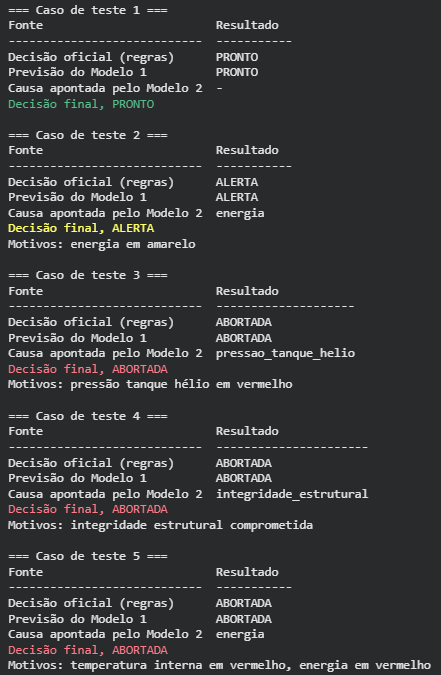